In [ ]:
from RAG.modules import logging

logging.langsmith("Model_RAG")

In [ ]:
from langgraph.graph import StateGraph, START, END
from RAG.types import state
from RAG.llm.model import get_OpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

In [3]:
from langchain.globals import set_verbose, set_debug

set_debug(True)
set_verbose(True)

In [4]:
llm = get_OpenAI()
output_parser = StrOutputParser()

In [5]:
from RAG.tools.call_Vehicle_tools import get_brand_list_tool, get_model_list_tool, get_year_list_tool, get_detail_list_tool, get_option_list_tool, HumanRequest, State, Vehicle, Headers

In [6]:
tools = [get_brand_list_tool, get_model_list_tool, get_year_list_tool, get_detail_list_tool, get_option_list_tool, HumanRequest]

In [7]:
# LLM 모델 초기화 및 도구 바인딩
llm_with_tools = llm.bind_tools(tools)

In [ ]:
# 도구 호출 확인
llm_with_tools.invoke("브랜드 리스트 알려줘").tool_calls

In [9]:
from langgraph.graph import StateGraph, MessagesState, START, END

In [10]:
tool_node = ToolNode(tools)

In [11]:
# LLM 모델을 사용하여 메시지 처리 및 응답 생성, 도구 호출이 포함된 응답 반환
def call_model(State: MessagesState):
    
    user_input = state.messages
    prompt=call_prompt()
    chain = prompt | llm_with_tools | output_parser
    
    # 사람에게 질문할지 여부 초기화
    ask_human = False
    
    response = chain.invoke(State.messages)
    
    
    # 도구 호출이 있고 이름이 'HumanRequest' 인 경우
    if response.tool_calls and response.tool_calls[0]["name"] == HumanRequest.__name__:
        ask_human = True

    # 메시지와 ask_human 상태 반환
    return {"messages": [response], "ask_human": ask_human}

In [12]:
from langchain_core.messages import AIMessage, ToolMessage


# 응답 메시지 생성(ToolMessage 생성을 위한 함수)
def create_response(response: str, ai_message: AIMessage):
    return ToolMessage(
        content=response,
        tool_call_id=ai_message.tool_calls[0]["id"],
    )


# 인간 노드 처리
def human_node(State: State):
    new_messages = []
    if not isinstance(state["messages"][-1], ToolMessage):
        # 사람으로부터 응답이 없는 경우
        new_messages.append(
            create_response("No response from human.", state["messages"][-1])
        )
    return {
        # 새 메시지 추가
        "messages": new_messages,
        # 플래그 해제
        "ask_human": False,
    }



In [13]:
def select_next_node(State: State):
    # 인간에게 질문 여부 확인
    if state["ask_human"]:
        return "human"
    # 이전과 동일한 경로 설정
    return tools_condition(State)

In [14]:
workflow = StateGraph(MessagesState)

In [ ]:
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

# 그래프에 인간 노드 추가
workflow.add_node("human", human_node)

In [16]:
# 워크플로우 시작점에서 에이전트 노드로 연결
workflow.add_edge(START, "agent")

# 에이전트 노드에서 조건부 분기 설정, 도구 노드 또는 종료 지점으로 연결
# 조건부 엣지 추가
workflow.add_conditional_edges(
    "agent",
    select_next_node,
    {"human": "human", "tools": "tools", END: END},
)
# 엣지 추가: 'tools'에서 'chatbot'으로
workflow.add_edge("tools", "agent")

# 엣지 추가: 'human'에서 'chatbot'으로
workflow.add_edge("human", "agent")

# 메모리 저장소 초기화
memory = MemorySaver()

# 정의된 워크플로우 그래프 컴파일 및 실행 가능한 애플리케이션 생성
# 그래프 컴파일: 메모리 체크포인터 사용
graph = workflow.compile(
    checkpointer=memory,
    # 'human' 이전에 인터럽트 설정
    interrupt_before=["human"],
)

In [ ]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [18]:
import os
from dotenv import load_dotenv
load_dotenv()

access_token = os.getenv("CODEF_ACCESS_TOKEN")

In [19]:
# user_input = "브랜드 조회해줘."

# # config 설정
# config = {"configurable": {"thread_id": "1"}}

# # 스트림 또는 호출의 두 번째 위치 인수로서의 구성
# events = graph.stream(
#     {"messages": [("user", user_input)]}, config, stream_mode="values"
# )
# for event in events:
#     if "messages" in event:
#         # 마지막 메시지의 예쁜 출력
#         event["messages"][-1].pretty_print()

In [20]:
headers: Headers={
    "Authorization": f"Bearer {access_token}",
    "Content-Type": "application/json"
}

State: State = {
    "messages": [{"role": "user", "human": "브랜드 조회해줘."}],
    "headers":headers,
    "vehicle":Vehicle(),
    "ask_human": bool
}
# config 설정
config = {"configurable": {"thread_id": "1"}}

In [ ]:
ㅇㅇㅇ

In [1]:
# 임시 코드
from pydantic import BaseModel
from typing_extensions import Annotated, Sequence, TypedDict
from langchain.schema import BaseMessage

# 헤더 모델 정의
class Headers(BaseMessage):
    Authorization: str
    Content_Type: str
    
class Vehicle(BaseMessage):
    brand: str = ""  # 기본값 설정
    model: str = ""
    date: int = 0
    year: str = ""
    detail: str = ""
    option: str = ""

class State(BaseMessage):
    headers : Headers
    vehicle: Vehicle
    messages: Annotated[Sequence[BaseMessage], "add_messages"]
    ask_human: bool


class HumanRequest(BaseModel):
    """Forward the conversation to an expert. Use when you can't assist directly or the user needs assistance that exceeds your authority.
    To use this function, pass the user's 'request' so that an expert can provide appropriate guidance.
    """

    request: str

LangSmith 추적을 시작합니다.
[프로젝트명]
Model_RAG


c:\WS\final-project\SKN03-FINAL-6Team\TailorLink_LLM\finance\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3577: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  exec(code_obj, self.user_global_ns, self.user_ns)


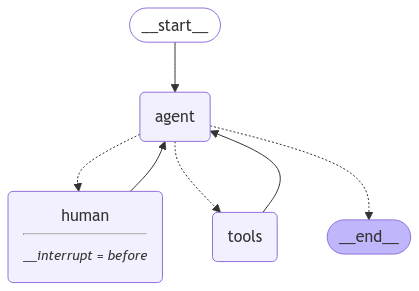

In [1]:
from RAG.modules import logging

logging.langsmith("Model_RAG")

# %%
from langgraph.graph import StateGraph, START, END
from RAG.types import state
from RAG.llm.model import get_OpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain.globals import set_verbose, set_debug

set_debug(True)
set_verbose(True)

llm = get_OpenAI()
output_parser = StrOutputParser()

from RAG.tools.call_Vehicle_tools import get_brand_list_tool, get_model_list_tool, get_year_list_tool, get_detail_list_tool, get_option_list_tool, HumanRequest, State, Vehicle, Headers

tools = [get_brand_list_tool, get_model_list_tool, get_year_list_tool, get_detail_list_tool, get_option_list_tool, HumanRequest]

# LLM 모델 초기화 및 도구 바인딩
llm_with_tools = llm.bind_tools(tools)

# %%
from langgraph.graph import StateGraph, MessagesState, START, END

# %%
tool_node = ToolNode(tools)

# %%
# Prompt 생성 함수
def call_prompt():
    return "Please provide the required information."

# %%
# LLM 모델을 사용하여 메시지 처리 및 응답 생성, 도구 호출이 포함된 응답 반환
def call_model(State: State):
    # 메시지 처리
    user_input = State.messages
    prompt = call_prompt()
    chain = prompt | llm_with_tools | output_parser

    # 사람에게 질문할지 여부 초기화
    ask_human = False

    # 응답 생성
    response = chain.invoke(user_input)

    # 도구 호출이 있고 이름이 'HumanRequest' 인 경우
    if response.tool_calls and response.tool_calls[0]["name"] == HumanRequest.__name__:
        ask_human = True

    
    # 메시지와 ask_human 상태 반환
    # return {"messages": [response], "ask_human": ask_human}
    return State

# %%
from langchain_core.messages import AIMessage, ToolMessage

# 응답 메시지 생성(ToolMessage 생성을 위한 함수)
def create_response(response: str, ai_message: AIMessage):
    return ToolMessage(
        content=response,
        tool_call_id=ai_message.tool_calls[0]["id"],
    )

# 인간 노드 처리
def human_node(State: State):
    new_messages = []
    if not isinstance(State["messages"][-1], ToolMessage):
        # 사람으로부터 응답이 없는 경우
        new_messages.append(
            create_response("No response from human.", State["messages"][-1])
        )
    return {
        # 새 메시지 추가
        "messages": new_messages,
        # 플래그 해제
        "ask_human": False,
    }

# %%
def select_next_node(State: State):
    # 인간에게 질문 여부 확인
    if state["ask_human"]:
        return "human"
    # 이전과 동일한 경로 설정
    return tools_condition(State)

# %%
workflow = StateGraph(MessagesState)

# %%
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

# 그래프에 인간 노드 추가
workflow.add_node("human", human_node)

# %%
# 워크플로우 시작점에서 에이전트 노드로 연결
workflow.add_edge(START, "agent")

# 에이전트 노드에서 조건부 분기 설정, 도구 노드 또는 종료 지점으로 연결
# 조건부 엣지 추가
workflow.add_conditional_edges(
    "agent",
    select_next_node,
    {"human": "human", "tools": "tools", END: END},
)
# 엣지 추가: 'tools'에서 'agent'로
workflow.add_edge("tools", "agent")

# 엣지 추가: 'human'에서 'agent'로
workflow.add_edge("human", "agent")

# 메모리 저장소 초기화
memory = MemorySaver()

# 정의된 워크플로우 그래프 컴파일 및 실행 가능한 애플리케이션 생성
# 그래프 컴파일: 메모리 체크포인터 사용
graph = workflow.compile(
    checkpointer=memory,
    # 'human' 이전에 인터럽트 설정
    interrupt_before=["human"],
)

from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

import os
from dotenv import load_dotenv
load_dotenv()

access_token = os.getenv("CODEF_ACCESS_TOKEN")

if not access_token:
    raise ValueError("CODEF_ACCESS_TOKEN is not set in the environment variables.")


In [2]:

headers: Headers = {
    "Authorization": f"Bearer {access_token}",
    "Content-Type": "application/json"
}


In [3]:
from langgraph.graph import MessagesState

# # Headers 객체 생성
# headers = Headers(
#     Authorization=f"Bearer {access_token}",
#     Content_Type="application/json"
# )

# # Vehicle 객체 생성
# vehicle = Vehicle()

# 초기 상태를 MessagesState로 설정
State : State = {
    "messages": [{"role": "user", "content": "브랜드 조회해줘."}],
    "headers" : headers,
    "vehicle" : Vehicle(),
    "ask_human": False
}

In [4]:
config = {"configurable": {"thread_id": "user_123"}} 

In [ ]:
# 최종 결과 저장
final_result = None

try:
    for result in graph.stream(state,config):
        print("Intermediate Result:", result)
        final_result = result  # 최종 결과 저장
except Exception as e:
    print("Error during execution:", e)

print("Final Result:", final_result)

In [5]:
# 그래프 실행
try:
    result = graph.invoke(state, config)
    print("Execution Result:", result)
except Exception as e:
    print("Error during execution:", e)

[chain/start] [chain:LangGraph] Entering Chain run with input:
[inputs]
[chain/start] [chain:LangGraph > chain:__start__] Entering Chain run with input:
[inputs]
[chain/start] [chain:LangGraph > chain:__start__ > chain:ChannelWrite<...>] Entering Chain run with input:
[inputs]
[chain/error] [chain:LangGraph > chain:__start__ > chain:ChannelWrite<...>] s] Chain run errored with error:
"InvalidUpdateError(\"Expected dict, got <class 'RAG.types.state'>\\nFor troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/INVALID_GRAPH_NODE_RETURN_VALUE\")Traceback (most recent call last):\n\n\n  File \"c:\\WS\\final-project\\SKN03-FINAL-6Team\\TailorLink_LLM\\finance\\.venv\\Lib\\site-packages\\langgraph\\utils\\runnable.py\", line 176, in invoke\n    ret = context.run(self.func, input, **kwargs)\n          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n\n\n  File \"c:\\WS\\final-project\\SKN03-FINAL-6Team\\TailorLink_LLM\\finance\\.venv\\Lib\\site-packages\\langgraph\\pregel\\

In [ ]:
print(result)

In [ ]:
state["messages"][-1].pretty_print()